# TypiClust Modified: Cosine Similarity Typicality

## Modification

This notebook replaces the **Euclidean distance-based** typicality measure from
Hacohen et al. (ICML 2022) with a **cosine similarity-based** variant:

| | Original (paper) | Modified (this notebook) |
|---|---|---|
| **Formula** | Typicality(x) = (1/K * sum \|\|x - x_i\|\|_2)^{-1} | Typicality(x) = 1/K * sum cos_sim(x, x_i) |
| **KNN metric** | Euclidean distance | Cosine distance (= 1 - cos_sim) |
| **Score range** | (0, inf) | (-1, 1] |
| **Aggregation** | Inverse of mean distance | Mean of similarities |

### Rationale

SimCLR features are L2-normalised and live on a **unit hypersphere**.  While
Euclidean distance between unit vectors is a monotone transform of cosine
distance (||a-b||^2 = 2 - 2*cos(a,b)), the *aggregation* differs:

- **Original**: takes the mean of distances, then inverts (1/x).  The 1/x
  non-linearity amplifies the influence of a single large distance, making
  the score sensitive to outlier neighbours.
- **Modified**: takes the mean of similarities directly.  This is a linear
  aggregation, so outlier neighbours have proportional (not amplified)
  influence, potentially making cosine typicality **more robust**.

### What stays the same

- SimCLR features (same checkpoint, no retraining)
- K-Means clustering step (identical clusters each round)
- Uncovered-cluster selection logic
- Classifier (ResNet-18 from scratch, same hyperparameters)
- Experiment protocol: B=10, 5 rounds, 3+ seeds

---

**Prerequisites:** run `tpcrp_original.ipynb` first to generate:
- `results/simclr_checkpoint.pt`
- `results/train_features.npy` / `results/test_features.npy`
- `results/train_labels.npy` / `results/test_labels.npy`

---
## Section 1: Setup & Imports

In [1]:
# Set working directory to Kaggle root
%cd /kaggle/working

# Remove existing repository folder
!rm -rf /kaggle/working/machine-learning-coursework-2

# Clone clean repository from main branch
!git clone -b main https://github.com/UlvisTurkers/machine-learning-coursework-2.git /kaggle/working/machine-learning-coursework-2

/kaggle/working
Cloning into '/kaggle/working/machine-learning-coursework-2'...
remote: Enumerating objects: 1086, done.
remote: Counting objects: 100% (1086/1086), done.
remote: Compressing objects: 100% (998/998), done.
remote: Total 1086 (delta 102), reused 1059 (delta 76), pack-reused 0 (from 0)
Receiving objects: 100% (1086/1086), 4.22 MiB | 22.38 MiB/s, done.
Resolving deltas: 100% (102/102), done.


In [11]:
import sys
import os
import importlib
import time
import glob
import shutil
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

REPO_DIR = "/kaggle/working/machine-learning-coursework-2"
%cd {REPO_DIR}

# Force Python to strictly recognize 'src' as a module
!touch src/__init__.py

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

for key in list(sys.modules.keys()):
    if key.startswith('src'):
        del sys.modules[key]
        
importlib.invalidate_caches()

# Import your custom functions
from src.utils import set_seed, load_cifar10, save_results
from src.classifier import CIFARClassifier, LinearClassifier
from src.active_learning import TypiClust, RandomSelection, TypiClustCosine

print("Success! Master imports are working.")

/kaggle/working/machine-learning-coursework-2
Success! Master imports are working.


In [12]:
GLOBAL_SEED = 42
set_seed(GLOBAL_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU    :', torch.cuda.get_device_name(0))

RESULTS_DIR = Path('./results')
PLOTS_DIR   = Path('./plots')
RESULTS_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

Device : cuda
GPU    : Tesla T4


In [13]:
# 1. Load the raw datasets (needed later for classifier data augmentation)
train_dataset, test_dataset = load_cifar10(root='./data')

print("Datasets loaded! Skipping SimCLR initialization because we have .npy features.")

Datasets loaded! Skipping SimCLR initialization because we have .npy features.


---
## Section 2: Load SAME SimCLR Features (no retraining)

In [15]:
# Results Directory and Feature Loading 
# Ensure the results directory exists locally
RESULTS_DIR = Path('./results')
RESULTS_DIR.mkdir(exist_ok=True)

# Define local file paths for features and labels
f_train_feats  = RESULTS_DIR / 'train_features.npy'
f_train_labels = RESULTS_DIR / 'train_labels.npy'
f_test_feats   = RESULTS_DIR / 'test_features.npy'
f_test_labels  = RESULTS_DIR / 'test_labels.npy'

# Check if pre-extracted features exist; if not, run extraction
# Note: This requires 'simclr_model', 'train_loader', and 'test_loader' to be defined
if not f_train_feats.exists():
    print("Notice: .npy files not found in ./results. Running extraction...")
    
    # Extract features using the model and data loaders defined in previous cells
    train_feats, train_labels = extract_features(simclr_model, train_loader, DEVICE)
    test_feats, test_labels   = extract_features(simclr_model, test_loader, DEVICE)

    # Save to current environment storage to allow quick loading later
    np.save(f_train_feats, train_feats)
    np.save(f_train_labels, train_labels)
    np.save(f_test_feats, test_feats)
    np.save(f_test_labels, test_labels)
    print("Notice: Extraction finished and files saved.")
else:
    print("Notice: Loading features from existing ./results cache...")
    train_feats  = np.load(str(f_train_feats))
    train_labels = np.load(str(f_train_labels))
    test_feats   = np.load(str(f_test_feats))
    test_labels  = np.load(str(f_test_labels))

# ── Dataset Metadata ────────────────────────────────────────────────────────
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck',
]
NUM_CLASSES = len(CIFAR10_CLASSES)

# ── Verification and Stats ──────────────────────────────────────────────────
norms = np.linalg.norm(train_feats, axis=1)
print('-' * 40)
print('Train features : {}   norm mean={:.4f}'.format(train_feats.shape, norms.mean()))
print('Test features  : {}'.format(test_feats.shape))
print('Features are L2-normalised: {}'.format('yes' if np.allclose(norms, 1.0, atol=1e-3) else 'NO'))

Notice: Loading features from existing ./results cache...
----------------------------------------
Train features : (50000, 512)   norm mean=1.0000
Test features  : (10000, 512)
Features are L2-normalised: yes


In [16]:
train_dataset, test_dataset = load_cifar10(root='../data')
print('Datasets loaded (needed for CIFARClassifier image augmentation).')

100%|██████████| 170M/170M [00:01<00:00, 104MB/s]  


Datasets loaded (needed for CIFARClassifier image augmentation).


---
## Section 3: Experiment Configuration

**Identical protocol** to `tpcrp_original.ipynb` — the only difference is
the typicality scoring function inside the modified selector.

In [17]:
BUDGET_B     = 10
N_ROUNDS     = 5
N_SEEDS      = 3       # same as original; increase to 10 for paper quality
CLF_EPOCHS   = 200
CLF_BATCH    = 64
MAX_CLUSTERS = 500
SEEDS        = list(range(N_SEEDS))

BUDGETS = [BUDGET_B * (r + 1) for r in range(N_ROUNDS)]
print('Budgets     :', BUDGETS)
print('Seeds       :', SEEDS)
total_runs = len(SEEDS) * N_ROUNDS * 3   # 3 strategies this time
print('Total classifier training runs: {} (3 strategies x {} seeds x {} rounds)'.format(
    total_runs, N_SEEDS, N_ROUNDS))

Budgets     : [10, 20, 30, 40, 50]
Seeds       : [0, 1, 2]
Total classifier training runs: 45 (3 strategies x 3 seeds x 5 rounds)


---
## Section 4: Shared AL Loop

This is the **exact same** experiment driver as `tpcrp_original.ipynb`.

In [18]:
def run_al_experiment(strategy_name, make_selector_fn, seeds):
    all_results = {}

    for seed in seeds:
        print('\n' + '=' * 60)
        print('  {}  |  seed={}'.format(strategy_name, seed))
        print('=' * 60)
        set_seed(seed)

        selector    = make_selector_fn(seed)
        clf         = CIFARClassifier(device=DEVICE, seed=seed, num_workers=2)
        labeled_idx = np.array([], dtype=np.int64)
        seed_records = []

        for rnd in range(N_ROUNDS):
            new_idx = selector.select(
                BUDGET_B,
                labeled_indices=labeled_idx if len(labeled_idx) > 0 else None,
            )
            labeled_idx = np.concatenate([labeled_idx, new_idx]).astype(np.int64)
            budget_now = len(labeled_idx)

            selected_classes = [CIFAR10_CLASSES[train_labels[i]] for i in new_idx]
            print('\n  Round {}/{} | labeled={}'.format(rnd + 1, N_ROUNDS, budget_now))
            print('  Selected classes:', selected_classes)

            t0 = time.time()
            train_hist = clf.train(
                labeled_idx, train_dataset,
                epochs=CLF_EPOCHS, batch_size=CLF_BATCH,
                seed=seed, verbose=False,
            )
            train_time = time.time() - t0

            eval_res = clf.evaluate(test_dataset)
            test_acc = eval_res['accuracy']

            print('  Test accuracy: {:.2f}%  (train {:.1f}s)'.format(test_acc, train_time))

            seed_records.append({
                'round':            rnd + 1,
                'budget':           int(budget_now),
                'test_accuracy':    float(test_acc),
                'per_class_acc':    eval_res['per_class_acc'].tolist(),
                'selected_indices': new_idx.tolist(),
                'final_train_loss': float(train_hist['train_loss'][-1]),
                'final_train_acc':  float(train_hist['train_acc'][-1]),
            })

        all_results[seed] = seed_records

    return all_results

In [19]:
def aggregate(results_dict):
    seeds_sorted = sorted(results_dict.keys())
    acc_matrix = np.array([
        [r['test_accuracy'] for r in results_dict[s]]
        for s in seeds_sorted
    ])
    budgets = [r['budget'] for r in results_dict[seeds_sorted[0]]]
    n_seeds = len(seeds_sorted)
    return {
        'mean':    acc_matrix.mean(axis=0),
        'std':     acc_matrix.std(axis=0, ddof=1) if n_seeds > 1 else np.zeros(len(budgets)),
        'matrix':  acc_matrix,
        'budgets': budgets,
    }

---
## Section 5: Run All Three Strategies

| Strategy | Typicality metric | KNN metric | What changed? |
|---|---|---|---|
| **TypiClust (original)** | Inverse mean Euclidean distance | Euclidean | Nothing (paper baseline) |
| **TypiClust (cosine)** | Mean cosine similarity | Cosine | Typicality scoring only |
| **Random** | N/A | N/A | Nothing (random baseline) |

In [20]:
%%time
# 1. Original TypiClust (Euclidean typicality)
print('='*60)
print(' ORIGINAL TypiClust (Euclidean typicality)')
print('='*60)

def make_original(seed):
    return TypiClust(
        features=train_feats, max_clusters=MAX_CLUSTERS,
        min_cluster_size=5, seed=seed,
    )

results_original = run_al_experiment('TypiClust-Euclidean', make_original, SEEDS)
save_results(
    {str(k): v for k, v in results_original.items()},
    str(RESULTS_DIR / 'modified_original_results.json'),
)
print('\nOriginal TypiClust complete.')

 ORIGINAL TypiClust (Euclidean typicality)

  TypiClust-Euclidean  |  seed=0

  Round 1/5 | labeled=10
  Selected classes: ['cat', 'deer', 'horse', 'airplane', 'ship', 'automobile', 'truck', 'frog', 'horse', 'bird']


  Test accuracy: 17.15%  (train 24.5s)

  Round 2/5 | labeled=20
  Selected classes: ['ship', 'horse', 'dog', 'airplane', 'horse', 'cat', 'truck', 'deer', 'automobile', 'dog']


  Test accuracy: 19.35%  (train 25.6s)

  Round 3/5 | labeled=30
  Selected classes: ['bird', 'frog', 'cat', 'automobile', 'ship', 'ship', 'airplane', 'dog', 'automobile', 'airplane']


  Test accuracy: 21.51%  (train 27.3s)

  Round 4/5 | labeled=40
  Selected classes: ['deer', 'truck', 'bird', 'cat', 'frog', 'automobile', 'automobile', 'deer', 'truck', 'bird']


  Test accuracy: 22.40%  (train 28.0s)

  Round 5/5 | labeled=50
  Selected classes: ['bird', 'truck', 'bird', 'dog', 'ship', 'frog', 'airplane', 'horse', 'horse', 'frog']


...

  Test accuracy: 15.52%  (train 22.6s)

  Round 2/5 | labeled=20
  Selected classes: ['cat', 'dog', 'bird', 'airplane', 'horse', 'deer', 'frog', 'truck', 'ship', 'automobile']


  Test accuracy: 19.58%  (train 24.8s)

  Round 3/5 | labeled=30
  Selected classes: ['bird', 'dog', 'truck', 'automobile', 'ship', 'automobile', 'dog', 'truck', 'airplane', 'airplane']


  Test accuracy: 20.64%  (train 27.5s)

  Round 4/5 | labeled=40
  Selected classes: ['cat', 'ship', 'deer', 'airplane', 'automobile', 'frog', 'frog', 'frog', 'automobile', 'horse']


  Test accuracy: 24.29%  (train 29.6s)

  Round 5/5 | labeled=50
  Selected classes: ['deer', 'cat', 'bird', 'automobile', 'dog', 'airplane', 'ship', 'horse', 'ship', 'automobile']


  Test accuracy: 23.82%  (train 30.9s)
Results saved to results/modified_original_results.json

Original TypiClust complete.
CPU times: user 32min 11s, sys: 2min 7s, total: 34min 19s
Wall time: 20min 38s


In [21]:
%%time
# 2. Modified TypiClust (Cosine typicality)
# ONLY the typicality scoring changes; clustering and selection logic are identical.
print('='*60)
print(' MODIFIED TypiClust (Cosine similarity typicality)')
print('='*60)

def make_cosine(seed):
    return TypiClustCosine(
        features=train_feats, max_clusters=MAX_CLUSTERS,
        min_cluster_size=5, seed=seed,
    )

results_cosine = run_al_experiment('TypiClust-Cosine', make_cosine, SEEDS)
save_results(
    {str(k): v for k, v in results_cosine.items()},
    str(RESULTS_DIR / 'modified_cosine_results.json'),
)
print('\nModified TypiClust (cosine) complete.')

 MODIFIED TypiClust (Cosine similarity typicality)

  TypiClust-Cosine  |  seed=0

  Round 1/5 | labeled=10
  Selected classes: ['cat', 'deer', 'horse', 'airplane', 'ship', 'automobile', 'truck', 'frog', 'horse', 'bird']


  Test accuracy: 14.27%  (train 24.7s)

  Round 2/5 | labeled=20
  Selected classes: ['ship', 'bird', 'horse', 'dog', 'airplane', 'horse', 'cat', 'truck', 'automobile', 'dog']


  Test accuracy: 19.55%  (train 27.5s)

  Round 3/5 | labeled=30
  Selected classes: ['bird', 'frog', 'cat', 'automobile', 'ship', 'ship', 'dog', 'automobile', 'airplane', 'airplane']


  Test accuracy: 21.72%  (train 29.2s)

  Round 4/5 | labeled=40
  Selected classes: ['deer', 'truck', 'deer', 'cat', 'frog', 'automobile', 'automobile', 'deer', 'truck', 'bird']


  Test accuracy: 22.83%  (train 29.4s)

  Round 5/5 | labeled=50
  Selected classes: ['bird', 'truck', 'bird', 'dog', 'ship', 'frog', 'airplane', 'horse', 'horse', 'frog']


...

  Test accuracy: 14.61%  (train 24.3s)

  Round 2/5 | labeled=20
  Selected classes: ['cat', 'deer', 'dog', 'bird', 'airplane', 'horse', 'frog', 'truck', 'ship', 'automobile']


  Test accuracy: 17.09%  (train 27.2s)

  Round 3/5 | labeled=30
  Selected classes: ['bird', 'dog', 'truck', 'automobile', 'ship', 'automobile', 'dog', 'truck', 'airplane', 'airplane']


  Test accuracy: 19.82%  (train 27.5s)

  Round 4/5 | labeled=40
  Selected classes: ['cat', 'ship', 'deer', 'automobile', 'frog', 'frog', 'airplane', 'frog', 'automobile', 'horse']


  Test accuracy: 23.09%  (train 28.4s)

  Round 5/5 | labeled=50
  Selected classes: ['cat', 'bird', 'automobile', 'dog', 'deer', 'airplane', 'ship', 'horse', 'ship', 'automobile']


  Test accuracy: 24.70%  (train 30.4s)
Results saved to results/modified_cosine_results.json

Modified TypiClust (cosine) complete.
CPU times: user 34min 14s, sys: 2min 24s, total: 36min 38s
Wall time: 21min 40s


In [22]:
%%time
# 3. Random baseline
print('='*60)
print(' RANDOM BASELINE')
print('='*60)

def make_random(seed):
    return RandomSelection(train_feats, seed=seed)

results_random = run_al_experiment('Random', make_random, SEEDS)
save_results(
    {str(k): v for k, v in results_random.items()},
    str(RESULTS_DIR / 'modified_random_results.json'),
)
print('\nRandom baseline complete.')

 RANDOM BASELINE

  Random  |  seed=0

  Round 1/5 | labeled=10
  Selected classes: ['bird', 'deer', 'frog', 'horse', 'bird', 'cat', 'ship', 'automobile', 'frog', 'deer']


  Test accuracy: 17.21%  (train 23.9s)

  Round 2/5 | labeled=20
  Selected classes: ['horse', 'frog', 'automobile', 'bird', 'airplane', 'frog', 'cat', 'truck', 'bird', 'automobile']


  Test accuracy: 19.63%  (train 26.9s)

  Round 3/5 | labeled=30
  Selected classes: ['frog', 'frog', 'dog', 'dog', 'deer', 'deer', 'frog', 'airplane', 'horse', 'ship']


  Test accuracy: 20.30%  (train 28.6s)

  Round 4/5 | labeled=40
  Selected classes: ['ship', 'cat', 'horse', 'dog', 'automobile', 'bird', 'cat', 'frog', 'dog', 'deer']


  Test accuracy: 20.47%  (train 29.7s)

  Round 5/5 | labeled=50
  Selected classes: ['bird', 'frog', 'cat', 'bird', 'dog', 'deer', 'ship', 'airplane', 'bird', 'horse']


...

  Test accuracy: 15.54%  (train 24.3s)

  Round 2/5 | labeled=20
  Selected classes: ['deer', 'deer', 'deer', 'automobile', 'truck', 'horse', 'automobile', 'airplane', 'horse', 'airplane']


  Test accuracy: 17.11%  (train 27.0s)

  Round 3/5 | labeled=30
  Selected classes: ['truck', 'dog', 'dog', 'cat', 'dog', 'frog', 'cat', 'horse', 'airplane', 'ship']


  Test accuracy: 21.18%  (train 28.4s)

  Round 4/5 | labeled=40
  Selected classes: ['deer', 'horse', 'horse', 'bird', 'cat', 'deer', 'ship', 'automobile', 'cat', 'truck']


  Test accuracy: 21.51%  (train 30.1s)

  Round 5/5 | labeled=50
  Selected classes: ['bird', 'ship', 'horse', 'horse', 'bird', 'bird', 'horse', 'truck', 'truck', 'deer']


  Test accuracy: 23.82%  (train 31.4s)
Results saved to results/modified_random_results.json

Random baseline complete.
CPU times: user 2min 57s, sys: 2min 21s, total: 5min 19s
Wall time: 7min 46s


In [23]:
# aggregate
agg_orig = aggregate(results_original)
agg_cos  = aggregate(results_cosine)
agg_rnd  = aggregate(results_random)
budgets_arr = np.array(agg_orig['budgets'])
print('Aggregation complete.')

Aggregation complete.


---
## Section 6: Comparison Table

In [24]:
header = '{:>8s}  {:>20s}  {:>20s}  {:>16s}'.format(
    'Budget', 'Original (Euclid)', 'Modified (Cosine)', 'Random')
print(header)
print('-' * len(header))

for i, b in enumerate(budgets_arr):
    orig_str = '{:.2f} +/- {:.2f}'.format(agg_orig['mean'][i], agg_orig['std'][i])
    cos_str  = '{:.2f} +/- {:.2f}'.format(agg_cos['mean'][i],  agg_cos['std'][i])
    rnd_str  = '{:.2f} +/- {:.2f}'.format(agg_rnd['mean'][i],  agg_rnd['std'][i])
    print('{:>8d}  {:>20s}  {:>20s}  {:>16s}'.format(b, orig_str, cos_str, rnd_str))

print()
print('Delta (cosine - original) at final budget: {:+.2f}%'.format(
    agg_cos['mean'][-1] - agg_orig['mean'][-1]))

  Budget     Original (Euclid)     Modified (Cosine)            Random
----------------------------------------------------------------------
      10        16.55 +/- 0.90        14.54 +/- 0.24    14.77 +/- 2.90
      20        19.45 +/- 0.12        18.62 +/- 1.34    17.44 +/- 2.04
      30        21.25 +/- 0.53        20.55 +/- 1.03    19.82 +/- 1.66
      40        23.17 +/- 0.99        22.80 +/- 0.31    21.04 +/- 0.53
      50        23.68 +/- 0.23        24.94 +/- 0.87    22.16 +/- 1.44

Delta (cosine - original) at final budget: +1.26%


In [25]:
# per-seed breakdown
for seed in SEEDS:
    orig_accs = ['{:.1f}'.format(r['test_accuracy']) for r in results_original[seed]]
    cos_accs  = ['{:.1f}'.format(r['test_accuracy']) for r in results_cosine[seed]]
    rnd_accs  = ['{:.1f}'.format(r['test_accuracy']) for r in results_random[seed]]
    print('Seed {}  Original: {}  Cosine: {}  Random: {}'.format(
        seed, orig_accs, cos_accs, rnd_accs))

Seed 0  Original: ['17.2', '19.4', '21.5', '22.4', '23.4']  Cosine: ['14.3', '19.6', '21.7', '22.8', '25.9']  Random: ['17.2', '19.6', '20.3', '20.5', '21.2']
Seed 1  Original: ['17.0', '19.4', '21.6', '22.8', '23.8']  Cosine: ['14.7', '19.2', '20.1', '22.5', '24.2']  Random: ['11.6', '15.6', '18.0', '21.1', '21.4']
Seed 2  Original: ['15.5', '19.6', '20.6', '24.3', '23.8']  Cosine: ['14.6', '17.1', '19.8', '23.1', '24.7']  Random: ['15.5', '17.1', '21.2', '21.5', '23.8']


---
## Section 7: Plots

In [26]:
plt.rcParams.update({
    'font.size':       11,
    'axes.titlesize':  13,
    'axes.labelsize':  11,
    'legend.fontsize': 10,
    'figure.dpi':      120,
})

ORIG_COLOR = '#1f77b4'   # blue
COS_COLOR  = '#2ca02c'   # green
RND_COLOR  = '#ff7f0e'   # orange

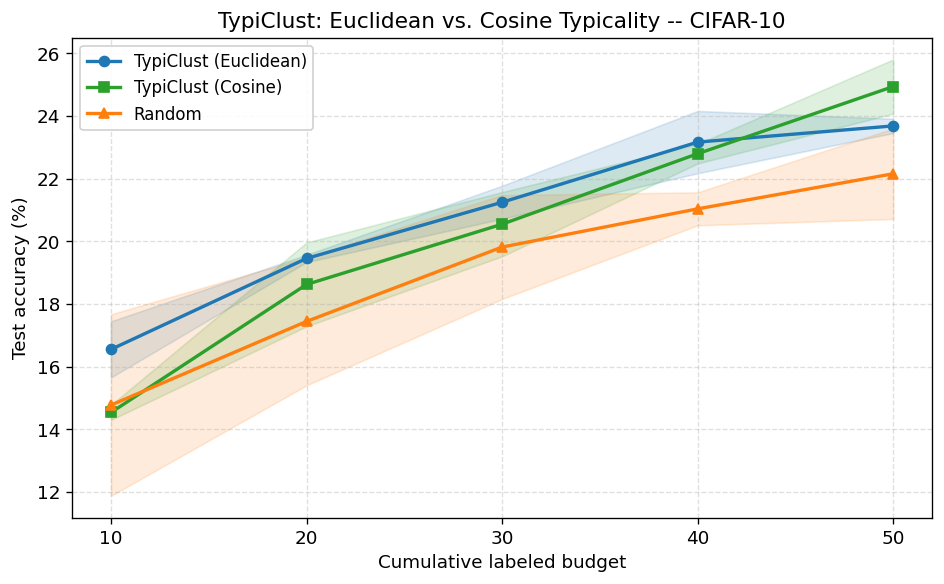

Saved -> plots/modified_accuracy_vs_budget.pdf
Saved -> plots/modified_fw1_comparison.pdf


In [27]:
# plot 1: Accuracy vs Budget (3 curves with std shading)
fig, ax = plt.subplots(figsize=(8, 5))

for agg, label, color, marker in [
    (agg_orig, 'TypiClust (Euclidean)', ORIG_COLOR, 'o'),
    (agg_cos,  'TypiClust (Cosine)',    COS_COLOR,  's'),
    (agg_rnd,  'Random',                RND_COLOR,  '^'),
]:
    mu  = agg['mean']
    std = agg['std']
    ax.plot(budgets_arr, mu, marker=marker, linewidth=2, color=color, label=label)
    ax.fill_between(budgets_arr, mu - std, mu + std, alpha=0.15, color=color)

ax.set_xlabel('Cumulative labeled budget')
ax.set_ylabel('Test accuracy (%)')
ax.set_title('TypiClust: Euclidean vs. Cosine Typicality -- CIFAR-10')
ax.set_xticks(budgets_arr)
ax.legend(framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.margins(x=0.05)

plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'modified_accuracy_vs_budget.pdf'), bbox_inches='tight')
plt.savefig(str(PLOTS_DIR / 'modified_fw1_comparison.pdf'),    bbox_inches='tight')
plt.show()
print('Saved -> plots/modified_accuracy_vs_budget.pdf')
print('Saved -> plots/modified_fw1_comparison.pdf')

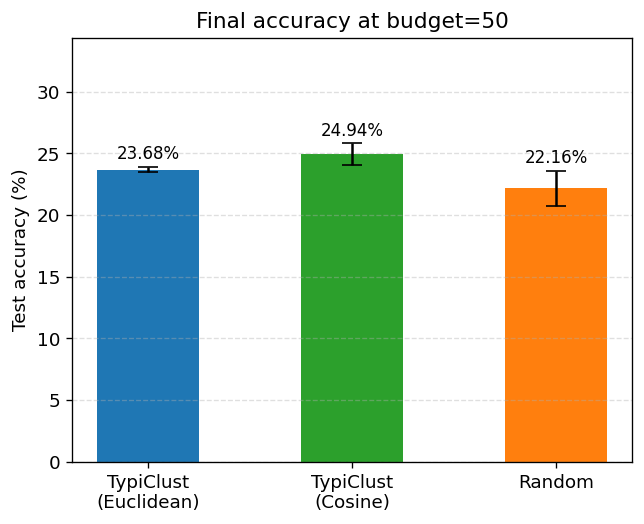

Saved -> plots/modified_final_bar.pdf


In [28]:
# plot 2: Bar chart at final budget
methods = ['TypiClust\n(Euclidean)', 'TypiClust\n(Cosine)', 'Random']
means   = [agg_orig['mean'][-1], agg_cos['mean'][-1], agg_rnd['mean'][-1]]
stds    = [agg_orig['std'][-1],  agg_cos['std'][-1],  agg_rnd['std'][-1]]
colors  = [ORIG_COLOR, COS_COLOR, RND_COLOR]

fig, ax = plt.subplots(figsize=(5.5, 4.5))
bars = ax.bar(methods, means, color=colors, width=0.5,
              yerr=stds, capsize=6, error_kw=dict(linewidth=1.5))

for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + s + 0.3,
            '{:.2f}%'.format(m),
            ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Test accuracy (%)')
ax.set_title('Final accuracy at budget={}'.format(BUDGETS[-1]))
ax.set_ylim(0, max(means) + max(stds) + 8)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'modified_final_bar.pdf'), bbox_inches='tight')
plt.show()
print('Saved -> plots/modified_final_bar.pdf')

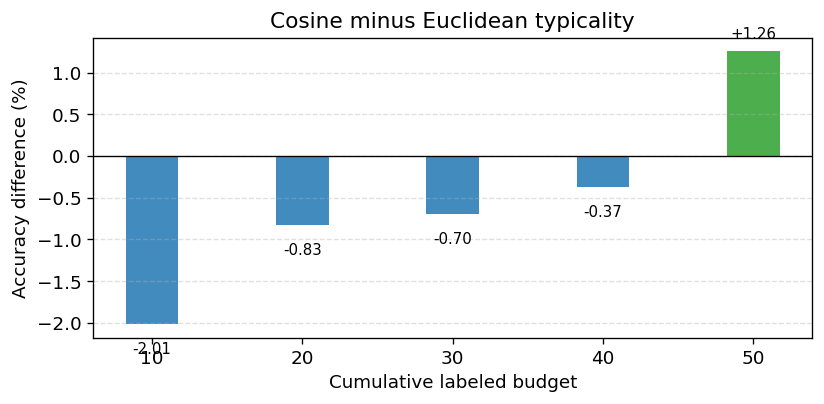

Saved -> plots/modified_delta_bar.pdf


In [29]:
# plot 3: Difference plot (Cosine - Original) per budget
deltas = agg_cos['mean'] - agg_orig['mean']

fig, ax = plt.subplots(figsize=(7, 3.5))
bar_colors = [COS_COLOR if d >= 0 else ORIG_COLOR for d in deltas]
ax.bar(budgets_arr, deltas, color=bar_colors, width=3.5, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)

for b, d in zip(budgets_arr, deltas):
    ax.text(b, d + (0.15 if d >= 0 else -0.35), '{:+.2f}'.format(d),
            ha='center', fontsize=9)

ax.set_xlabel('Cumulative labeled budget')
ax.set_ylabel('Accuracy difference (%)')
ax.set_title('Cosine minus Euclidean typicality')
ax.set_xticks(budgets_arr)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'modified_delta_bar.pdf'), bbox_inches='tight')
plt.show()
print('Saved -> plots/modified_delta_bar.pdf')

---
## Section 8: Statistical Analysis

Two comparisons at each budget level:
1. **Original vs. Modified** — is cosine typicality significantly different?
2. **Modified vs. Random** — does the modification still beat random?

In [30]:
def cohens_d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    diff = a - b
    sd = diff.std(ddof=1)
    if sd == 0:
        return 0.0
    return float(diff.mean() / sd)

def interpret_d(d):
    ad = abs(d)
    if ad < 0.2: return 'negligible'
    if ad < 0.5: return 'small'
    if ad < 0.8: return 'medium'
    return 'large'

In [31]:
if N_SEEDS < 2:
    print('WARNING: N_SEEDS < 2 -- cannot run statistical tests.')
    stat_orig_vs_cos = []
    stat_cos_vs_rnd  = []
else:
    # test 1: Original vs. Cosine (the core comparison)
    print('Paired t-test: Original (Euclidean) vs. Modified (Cosine)\n')
    header = '{:>8s}  {:>9s}  {:>9s}  {:>8s}  {:>9s}  {:>7s}  {:>9s}  {:>10s}'.format(
        'Budget', 'Orig', 'Cosine', 't-stat', 'p-value', 'Sig', "Cohen d", 'Effect')
    print(header)
    print('-' * len(header))

    stat_orig_vs_cos = []
    for i, b in enumerate(budgets_arr):
        a = agg_orig['matrix'][:, i]
        c = agg_cos['matrix'][:, i]
        t_stat, p_val = stats.ttest_rel(c, a)   # positive t => cosine > original
        d = cohens_d(c, a)
        sig = '*' if p_val < 0.05 else ('~' if p_val < 0.10 else '')
        print('{:>8d}  {:>8.2f}%  {:>8.2f}%  {:>8.3f}  {:>9.4f}  {:>7s}  {:>9.3f}  {:>10s}'.format(
            b, a.mean(), c.mean(), t_stat, p_val, sig, d, interpret_d(d)))
        stat_orig_vs_cos.append({
            'budget': int(b), 't_stat': float(t_stat),
            'p_value': float(p_val), 'cohens_d': float(d),
        })

    print('\n  * p < 0.05   ~ p < 0.10')

    # test 2: Cosine vs. Random
    print('\n\nPaired t-test: Modified (Cosine) vs. Random\n')
    print(header)
    print('-' * len(header))

    stat_cos_vs_rnd = []
    for i, b in enumerate(budgets_arr):
        c = agg_cos['matrix'][:, i]
        r = agg_rnd['matrix'][:, i]
        t_stat, p_val = stats.ttest_rel(c, r)
        d = cohens_d(c, r)
        sig = '*' if p_val < 0.05 else ('~' if p_val < 0.10 else '')
        print('{:>8d}  {:>8.2f}%  {:>8.2f}%  {:>8.3f}  {:>9.4f}  {:>7s}  {:>9.3f}  {:>10s}'.format(
            b, c.mean(), r.mean(), t_stat, p_val, sig, d, interpret_d(d)))
        stat_cos_vs_rnd.append({
            'budget': int(b), 't_stat': float(t_stat),
            'p_value': float(p_val), 'cohens_d': float(d),
        })

    print('\n  * p < 0.05   ~ p < 0.10')

    save_results(
        {'original_vs_cosine': stat_orig_vs_cos, 'cosine_vs_random': stat_cos_vs_rnd},
        str(RESULTS_DIR / 'modified_statistical_analysis.json'),
    )

Paired t-test: Original (Euclidean) vs. Modified (Cosine)

  Budget       Orig     Cosine    t-stat    p-value      Sig    Cohen d      Effect
-----------------------------------------------------------------------------------
      10     16.55%     14.54%    -3.466     0.0741        ~     -2.001       large
      20     19.45%     18.62%    -0.990     0.4263              -0.572      medium
      30     21.25%     20.55%    -1.416     0.2925              -0.817       large
      40     23.17%     22.80%    -0.786     0.5142              -0.454       small
      50     23.68%     24.94%     2.006     0.1827               1.158       large

  * p < 0.05   ~ p < 0.10


Paired t-test: Modified (Cosine) vs. Random

  Budget       Orig     Cosine    t-stat    p-value      Sig    Cohen d      Effect
-----------------------------------------------------------------------------------
      10     14.54%     14.77%    -0.132     0.9072              -0.076  negligible
      20     18.62%     17.

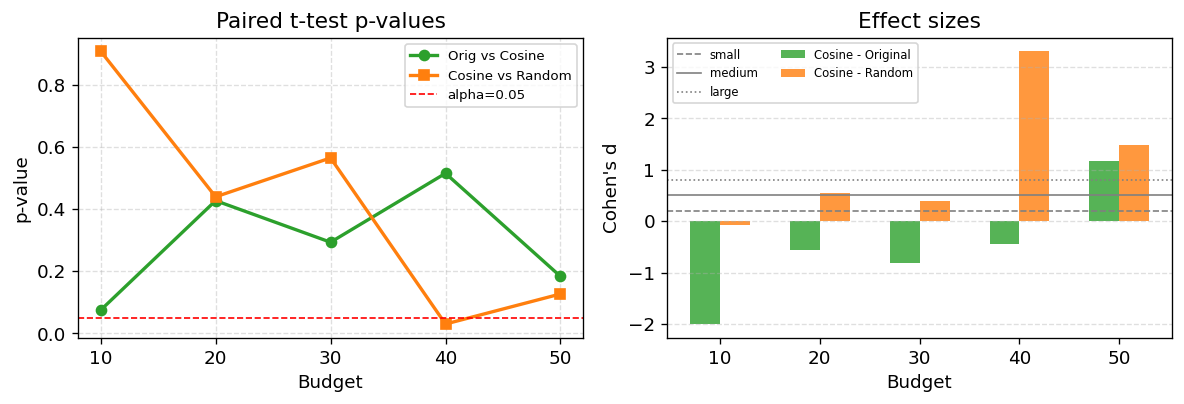

Saved -> plots/modified_statistical.pdf


In [32]:
# statistical analysis plot
if N_SEEDS >= 2 and len(stat_orig_vs_cos) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

    # p-values: Orig vs Cosine
    ax = axes[0]
    p_oc = [r['p_value'] for r in stat_orig_vs_cos]
    p_cr = [r['p_value'] for r in stat_cos_vs_rnd]
    ax.plot(budgets_arr, p_oc, marker='o', color=COS_COLOR, linewidth=2,
            label='Orig vs Cosine')
    ax.plot(budgets_arr, p_cr, marker='s', color=RND_COLOR, linewidth=2,
            label='Cosine vs Random')
    ax.axhline(0.05, color='red', linestyle='--', linewidth=1, label='alpha=0.05')
    ax.set_xlabel('Budget')
    ax.set_ylabel('p-value')
    ax.set_title('Paired t-test p-values')
    ax.set_xticks(budgets_arr)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

    # Cohen's d: Orig vs Cosine
    ax = axes[1]
    d_oc = [r['cohens_d'] for r in stat_orig_vs_cos]
    d_cr = [r['cohens_d'] for r in stat_cos_vs_rnd]
    w = 1.5
    ax.bar(budgets_arr - w, d_oc, width=2*w, color=COS_COLOR, alpha=0.8,
           label='Cosine - Original')
    ax.bar(budgets_arr + w, d_cr, width=2*w, color=RND_COLOR, alpha=0.8,
           label='Cosine - Random')
    for thresh, lbl, ls in [(0.2, 'small', '--'), (0.5, 'medium', '-'), (0.8, 'large', ':')]:
        ax.axhline(thresh, color='gray', linestyle=ls, linewidth=1, label=lbl)
    ax.set_xlabel('Budget')
    ax.set_ylabel("Cohen's d")
    ax.set_title('Effect sizes')
    ax.set_xticks(budgets_arr)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig(str(PLOTS_DIR / 'modified_statistical.pdf'), bbox_inches='tight')
    plt.show()
    print('Saved -> plots/modified_statistical.pdf')
else:
    print('Skipping plots (need N_SEEDS >= 2).')

---
## Section 9: Summary

In [33]:
W = 82
sep  = '-' * W
dsep = '=' * W

print(dsep)
print('{:^{}s}'.format('MODIFIED TypiClust: Euclidean vs. Cosine Typicality', W))
print('{:^{}s}'.format('CIFAR-10  |  B={}, {} rounds, {} seeds'.format(BUDGET_B, N_ROUNDS, N_SEEDS), W))
print(dsep)
print('{:>8s}  |  {:^22s}  |  {:^22s}  |  {:^14s}'.format(
    'Budget', 'Original (Euclid)', 'Modified (Cosine)', 'Random'))
print('{:>8s}  |  {:^22s}  |  {:^22s}  |  {:^14s}'.format(
    '', 'mean +/- std', 'mean +/- std', 'mean +/- std'))
print(sep)

for i, b in enumerate(budgets_arr):
    orig_str = '{:.2f} +/- {:.2f}'.format(agg_orig['mean'][i], agg_orig['std'][i])
    cos_str  = '{:.2f} +/- {:.2f}'.format(agg_cos['mean'][i],  agg_cos['std'][i])
    rnd_str  = '{:.2f} +/- {:.2f}'.format(agg_rnd['mean'][i],  agg_rnd['std'][i])
    print('{:>8d}  |  {:^22s}  |  {:^22s}  |  {:^14s}'.format(
        int(b), orig_str, cos_str, rnd_str))

print(dsep)
print('\nFinal budget ({} labels):'.format(BUDGETS[-1]))
print('  Original (Euclidean) : {:.2f}% +/- {:.2f}%'.format(
    agg_orig['mean'][-1], agg_orig['std'][-1]))
print('  Modified (Cosine)    : {:.2f}% +/- {:.2f}%'.format(
    agg_cos['mean'][-1], agg_cos['std'][-1]))
print('  Random               : {:.2f}% +/- {:.2f}%'.format(
    agg_rnd['mean'][-1], agg_rnd['std'][-1]))
print('  Delta (Cosine - Orig): {:+.2f}%'.format(
    agg_cos['mean'][-1] - agg_orig['mean'][-1]))
print('  Delta (Cosine - Rand): {:+.2f}%'.format(
    agg_cos['mean'][-1] - agg_rnd['mean'][-1]))
print(dsep)

               MODIFIED TypiClust: Euclidean vs. Cosine Typicality                
                       CIFAR-10  |  B=10, 5 rounds, 3 seeds                       
  Budget  |    Original (Euclid)     |    Modified (Cosine)     |      Random    
          |       mean +/- std       |       mean +/- std       |   mean +/- std 
----------------------------------------------------------------------------------
      10  |      16.55 +/- 0.90      |      14.54 +/- 0.24      |  14.77 +/- 2.90
      20  |      19.45 +/- 0.12      |      18.62 +/- 1.34      |  17.44 +/- 2.04
      30  |      21.25 +/- 0.53      |      20.55 +/- 1.03      |  19.82 +/- 1.66
      40  |      23.17 +/- 0.99      |      22.80 +/- 0.31      |  21.04 +/- 0.53
      50  |      23.68 +/- 0.23      |      24.94 +/- 0.87      |  22.16 +/- 1.44

Final budget (50 labels):
  Original (Euclidean) : 23.68% +/- 0.23%
  Modified (Cosine)    : 24.94% +/- 0.87%
  Random               : 22.16% +/- 1.44%
  Delta (Cosine - Orig):

---
## Section 9b: Framework 2 -- Linear Classifier on Frozen SimCLR Features

So far the comparison between **Euclidean** and **Cosine** typicality has only
been evaluated under Framework 1 (ResNet-18 trained from scratch). The Q&A
asks that the modification be evaluated under **multiple frameworks**, so this
section repeats the same three-way comparison with Framework 2:

- a single `nn.Linear(512, 10)` head
- trained directly on the frozen, L2-normalised SimCLR features
- 100 epochs, SGD + cosine LR, no image augmentation

The selectors are unchanged -- only the downstream classifier is swapped --
so any difference between the two frameworks is purely a property of the
classifier, not of the active learning algorithm.

In [34]:
# framework 2 hyperparameters (must match tpcrp_original.ipynb Section 4b)
FW2_EPOCHS = 100
FW2_LR     = 0.1
FW2_BATCH  = 256

print('Framework 2 setup:')
print('  classifier  : nn.Linear(512, 10)')
print('  features    : frozen SimCLR (no augmentation)')
print('  epochs      : {}'.format(FW2_EPOCHS))
print('  lr / batch  : {} / {}'.format(FW2_LR, FW2_BATCH))
print('  train_feats : {}'.format(train_feats.shape))
print('  test_feats  : {}'.format(test_feats.shape))

Framework 2 setup:
  classifier  : nn.Linear(512, 10)
  features    : frozen SimCLR (no augmentation)
  epochs      : 100
  lr / batch  : 0.1 / 256
  train_feats : (50000, 512)
  test_feats  : (10000, 512)


In [35]:
def run_al_experiment_fw2(strategy_name, make_selector_fn, seeds):
    all_results = {}

    for seed in seeds:
        print('\n' + '=' * 60)
        print('  {}  |  seed={}'.format(strategy_name, seed))
        print('=' * 60)
        set_seed(seed)

        selector    = make_selector_fn(seed)
        clf         = LinearClassifier(
            input_dim=512, num_classes=NUM_CLASSES,
            device=DEVICE, seed=seed,
        )
        labeled_idx = np.array([], dtype=np.int64)
        seed_records = []

        for rnd in range(N_ROUNDS):
            new_idx = selector.select(
                BUDGET_B,
                labeled_indices=labeled_idx if len(labeled_idx) > 0 else None,
            )
            labeled_idx = np.concatenate([labeled_idx, new_idx]).astype(np.int64)
            budget_now = len(labeled_idx)

            print('\n  Round {}/{} | labeled={}'.format(rnd + 1, N_ROUNDS, budget_now))

            t0 = time.time()
            train_hist = clf.train(
                labeled_idx, train_feats, train_labels,
                epochs=FW2_EPOCHS, batch_size=FW2_BATCH, lr=FW2_LR,
                seed=seed,
            )
            train_time = time.time() - t0

            eval_res = clf.evaluate(test_feats, test_labels)
            test_acc = eval_res['accuracy']

            print('  Test accuracy: {:.2f}%  (train {:.1f}s)'.format(test_acc, train_time))

            seed_records.append({
                'round':            rnd + 1,
                'budget':           int(budget_now),
                'test_accuracy':    float(test_acc),
                'per_class_acc':    eval_res['per_class_acc'].tolist(),
                'selected_indices': new_idx.tolist(),
                'final_train_loss': float(train_hist['train_loss'][-1]),
                'final_train_acc':  float(train_hist['train_acc'][-1]),
            })

        all_results[seed] = seed_records

    return all_results

In [36]:
%%time
# 1. Original TypiClust (Euclidean typicality) -- Framework 2
print('=' * 60)
print(' FW2 -- Original TypiClust (Euclidean)')
print('=' * 60)

results_fw2_original = run_al_experiment_fw2(
    'TypiClust-Euclidean-FW2', make_original, SEEDS,
)
save_results(
    {str(k): v for k, v in results_fw2_original.items()},
    str(RESULTS_DIR / 'modified_fw2_original_results.json'),
)
print('\nFW2 original complete.')

 FW2 -- Original TypiClust (Euclidean)

  TypiClust-Euclidean-FW2  |  seed=0

  Round 1/5 | labeled=10
  Test accuracy: 60.50%  (train 0.1s)

  Round 2/5 | labeled=20
  Test accuracy: 52.30%  (train 0.1s)

  Round 3/5 | labeled=30
  Test accuracy: 68.13%  (train 0.1s)

  Round 4/5 | labeled=40
  Test accuracy: 81.45%  (train 0.2s)

  Round 5/5 | labeled=50
  Test accuracy: 82.65%  (train 0.2s)

  TypiClust-Euclidean-FW2  |  seed=1

  Round 1/5 | labeled=10
  Test accuracy: 61.20%  (train 0.1s)

  Round 2/5 | labeled=20
  Test accuracy: 69.32%  (train 0.1s)

  Round 3/5 | labeled=30
  Test accuracy: 76.02%  (train 0.1s)

  Round 4/5 | labeled=40
  Test accuracy: 82.30%  (train 0.2s)

  Round 5/5 | labeled=50
  Test accuracy: 79.98%  (train 0.2s)

  TypiClust-Euclidean-FW2  |  seed=2

  Round 1/5 | labeled=10
  Test accuracy: 60.41%  (train 0.1s)

  Round 2/5 | labeled=20
  Test accuracy: 72.27%  (train 0.1s)

  Round 3/5 | labeled=30
  Test accuracy: 73.17%  (train 0.1s)

  Round 4/5 | 

In [37]:
%%time
# 2. Modified TypiClust (Cosine typicality) -- Framework 2
print('=' * 60)
print(' FW2 -- Modified TypiClust (Cosine)')
print('=' * 60)

results_fw2_cosine = run_al_experiment_fw2(
    'TypiClust-Cosine-FW2', make_cosine, SEEDS,
)
save_results(
    {str(k): v for k, v in results_fw2_cosine.items()},
    str(RESULTS_DIR / 'modified_fw2_cosine_results.json'),
)
print('\nFW2 cosine complete.')

 FW2 -- Modified TypiClust (Cosine)

  TypiClust-Cosine-FW2  |  seed=0

  Round 1/5 | labeled=10
  Test accuracy: 58.88%  (train 0.1s)

  Round 2/5 | labeled=20
  Test accuracy: 50.66%  (train 0.1s)

  Round 3/5 | labeled=30
  Test accuracy: 67.30%  (train 0.2s)

  Round 4/5 | labeled=40
  Test accuracy: 81.56%  (train 0.2s)

  Round 5/5 | labeled=50
  Test accuracy: 82.53%  (train 0.2s)

  TypiClust-Cosine-FW2  |  seed=1

  Round 1/5 | labeled=10
  Test accuracy: 59.94%  (train 0.1s)

  Round 2/5 | labeled=20
  Test accuracy: 67.51%  (train 0.1s)

  Round 3/5 | labeled=30
  Test accuracy: 74.90%  (train 0.2s)

  Round 4/5 | labeled=40
  Test accuracy: 76.11%  (train 0.2s)

  Round 5/5 | labeled=50
  Test accuracy: 83.31%  (train 0.2s)

  TypiClust-Cosine-FW2  |  seed=2

  Round 1/5 | labeled=10
  Test accuracy: 58.90%  (train 0.1s)

  Round 2/5 | labeled=20
  Test accuracy: 71.18%  (train 0.2s)

  Round 3/5 | labeled=30
  Test accuracy: 71.75%  (train 0.2s)

  Round 4/5 | labeled=40
 

In [38]:
%%time
# 3. Random baseline -- Framework 2
print('=' * 60)
print(' FW2 -- Random Baseline')
print('=' * 60)

results_fw2_random = run_al_experiment_fw2(
    'Random-FW2', make_random, SEEDS,
)
save_results(
    {str(k): v for k, v in results_fw2_random.items()},
    str(RESULTS_DIR / 'modified_fw2_random_results.json'),
)
print('\nFW2 random complete.')

 FW2 -- Random Baseline

  Random-FW2  |  seed=0

  Round 1/5 | labeled=10
  Test accuracy: 47.85%  (train 0.1s)

  Round 2/5 | labeled=20
  Test accuracy: 46.79%  (train 0.1s)

  Round 3/5 | labeled=30
  Test accuracy: 49.51%  (train 0.1s)

  Round 4/5 | labeled=40
  Test accuracy: 59.12%  (train 0.2s)

  Round 5/5 | labeled=50
  Test accuracy: 61.32%  (train 0.2s)

  Random-FW2  |  seed=1

  Round 1/5 | labeled=10
  Test accuracy: 33.38%  (train 0.1s)

  Round 2/5 | labeled=20
  Test accuracy: 50.88%  (train 0.1s)

  Round 3/5 | labeled=30
  Test accuracy: 63.76%  (train 0.1s)

  Round 4/5 | labeled=40
  Test accuracy: 63.67%  (train 0.2s)

  Round 5/5 | labeled=50
  Test accuracy: 60.53%  (train 0.2s)

  Random-FW2  |  seed=2

  Round 1/5 | labeled=10
  Test accuracy: 36.35%  (train 0.1s)

  Round 2/5 | labeled=20
  Test accuracy: 58.21%  (train 0.1s)

  Round 3/5 | labeled=30
  Test accuracy: 61.62%  (train 0.1s)

  Round 4/5 | labeled=40
  Test accuracy: 64.44%  (train 0.1s)

  Ro

In [39]:
# aggregate FW2 results (uses the same aggregate() defined in Section 4)
agg_fw2_orig = aggregate(results_fw2_original)
agg_fw2_cos  = aggregate(results_fw2_cosine)
agg_fw2_rnd  = aggregate(results_fw2_random)

W = 82
print('=' * W)
print('{:^{}s}'.format('Framework 2: Linear Classifier on Frozen SimCLR Features', W))
print('{:^{}s}'.format('CIFAR-10  |  B={}, {} rounds, {} seeds'.format(BUDGET_B, N_ROUNDS, N_SEEDS), W))
print('=' * W)
print('{:>8s}  |  {:^22s}  |  {:^22s}  |  {:^14s}'.format(
    'Budget', 'Original (Euclid)', 'Modified (Cosine)', 'Random'))
print('{:>8s}  |  {:^22s}  |  {:^22s}  |  {:^14s}'.format(
    '', 'mean +/- std', 'mean +/- std', 'mean +/- std'))
print('-' * W)

for i, b in enumerate(budgets_arr):
    o = '{:.2f} +/- {:.2f}'.format(agg_fw2_orig['mean'][i], agg_fw2_orig['std'][i])
    c = '{:.2f} +/- {:.2f}'.format(agg_fw2_cos['mean'][i],  agg_fw2_cos['std'][i])
    r = '{:.2f} +/- {:.2f}'.format(agg_fw2_rnd['mean'][i],  agg_fw2_rnd['std'][i])
    print('{:>8d}  |  {:^22s}  |  {:^22s}  |  {:^14s}'.format(int(b), o, c, r))

print('=' * W)
print('Final budget ({} labels):'.format(BUDGETS[-1]))
print('  Original (Euclidean) : {:.2f}% +/- {:.2f}%'.format(
    agg_fw2_orig['mean'][-1], agg_fw2_orig['std'][-1]))
print('  Modified (Cosine)    : {:.2f}% +/- {:.2f}%'.format(
    agg_fw2_cos['mean'][-1], agg_fw2_cos['std'][-1]))
print('  Random               : {:.2f}% +/- {:.2f}%'.format(
    agg_fw2_rnd['mean'][-1], agg_fw2_rnd['std'][-1]))
print('  Delta (Cosine - Orig): {:+.2f}%'.format(
    agg_fw2_cos['mean'][-1] - agg_fw2_orig['mean'][-1]))
print('  Delta (Cosine - Rand): {:+.2f}%'.format(
    agg_fw2_cos['mean'][-1] - agg_fw2_rnd['mean'][-1]))

             Framework 2: Linear Classifier on Frozen SimCLR Features             
                       CIFAR-10  |  B=10, 5 rounds, 3 seeds                       
  Budget  |    Original (Euclid)     |    Modified (Cosine)     |      Random    
          |       mean +/- std       |       mean +/- std       |   mean +/- std 
----------------------------------------------------------------------------------
      10  |      60.70 +/- 0.43      |      59.24 +/- 0.61      |  39.19 +/- 7.64
      20  |     64.63 +/- 10.78      |     63.12 +/- 10.94      |  51.96 +/- 5.79
      30  |      72.44 +/- 4.00      |      71.32 +/- 3.82      |  58.30 +/- 7.68
      40  |      79.69 +/- 3.80      |      77.09 +/- 4.07      |  62.41 +/- 2.88
      50  |      80.88 +/- 1.53      |      81.85 +/- 1.89      |  60.08 +/- 1.52
Final budget (50 labels):
  Original (Euclidean) : 80.88% +/- 1.53%
  Modified (Cosine)    : 81.85% +/- 1.89%
  Random               : 60.08% +/- 1.52%
  Delta (Cosine - Orig): 

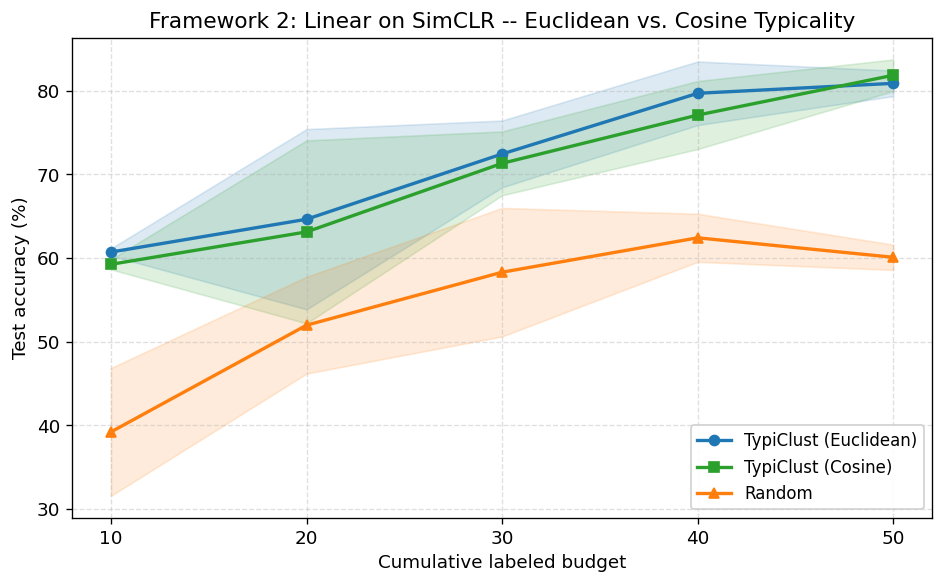

Saved -> plots/modified_fw2_comparison.pdf


In [40]:
# Framework 2 comparison plot (3 curves with std shading)
fig, ax = plt.subplots(figsize=(8, 5))

for agg, label, color, marker in [
    (agg_fw2_orig, 'TypiClust (Euclidean)', ORIG_COLOR, 'o'),
    (agg_fw2_cos,  'TypiClust (Cosine)',    COS_COLOR,  's'),
    (agg_fw2_rnd,  'Random',                RND_COLOR,  '^'),
]:
    mu  = agg['mean']
    std = agg['std']
    ax.plot(budgets_arr, mu, marker=marker, linewidth=2, color=color, label=label)
    ax.fill_between(budgets_arr, mu - std, mu + std, alpha=0.15, color=color)

ax.set_xlabel('Cumulative labeled budget')
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Framework 2: Linear on SimCLR -- Euclidean vs. Cosine Typicality')
ax.set_xticks(budgets_arr)
ax.legend(framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.margins(x=0.05)

plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'modified_fw2_comparison.pdf'), bbox_inches='tight')
plt.show()
print('Saved -> plots/modified_fw2_comparison.pdf')

---
## Section 10: Discussion

Fill in after running the experiments:

### Does cosine typicality improve over Euclidean?

*Your analysis here.* Consider:
- At which budget levels does the modification help/hurt?
- Are the differences statistically significant?
- Does the effect size suggest a meaningful practical difference?

### Why might the results differ (or not)?

For L2-normalised vectors on the unit sphere:
- `||a - b||_2^2 = 2 - 2 * cos(a, b)`
- So Euclidean distance and cosine distance identify the **same** nearest neighbours
- The key difference is in the aggregation:
  - **Euclidean typicality**: `1 / mean(distances)` -- the inverse makes it non-linear, amplifying the effect of one large distance among otherwise small ones
  - **Cosine typicality**: `mean(similarities)` -- linear average, so each neighbour contributes proportionally
- If all K neighbours are at similar distances, both methods agree
- If one neighbour is much farther, Euclidean typicality drops more sharply

### Practical implications

- Is the modification worth the added complexity for practitioners?
- Under what conditions might the difference become larger?
  (e.g., noisier features, higher K, different datasets)

In [41]:
# list all outputs from this notebook
print('Generated files:')
for pattern in ['../results/modified_*.json', '../plots/modified_*.pdf']:
    for f in sorted(glob.glob(pattern)):
        size_kb = Path(f).stat().st_size / 1024
        print('  {}  ({:.1f} KB)'.format(f, size_kb))

Generated files:
